# Land Cover Classification

## Step 2 - apply data

Use machine learning to classify snow covered areas. Use the 'hyriver' environment.

In [1]:
from supportingscripts import labeler, model_funcs, plotting
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from joblib import dump
from joblib import load
import numpy as np
import rasterio
import os
import matplotlib.pyplot as plt

In [2]:
labels_df = labeler.labeling_session(
    image_folder="data/LandSat/Uintas",
    n_samples=30,
    crop_size=100,
    patch_size=5,
    out_csv="data/LandSat/Uintas/training_samples.csv"
)

#1 is snow, 0 is no snow

Saved 25 pixels ✔
Saved 25 pixels.

Saved labels to data/LandSat/Uintas/training_samples.csv


In [3]:
#open file in excel to view
labels =  pd.read_csv("data/LandSat/GSL/training_samples.csv")
labels.head(30)

,blue,green,red,ndwi,brightness,label,source_file
0,0.298520,0.145017,0.246445,-0.259099,0.229994,0,GSL_2016_05.tif
1,0.280220,0.151506,0.236318,-0.218686,0.222682,0,GSL_2016_05.tif
2,0.311814,0.149093,0.249609,-0.252109,0.236839,0,GSL_2016_05.tif
3,0.330218,0.158392,0.253565,-0.231027,0.247391,0,GSL_2016_05.tif
4,0.324555,0.154118,0.247394,-0.232311,0.242022,0,GSL_2016_05.tif
5,0.297899,0.146046,0.250638,-0.263665,0.231527,0,GSL_2016_05.tif
6,0.299970,0.155780,0.250400,-0.232951,0.235384,0,GSL_2016_05.tif
7,0.312815,0.166543,0.253169,-0.206395,0.244176,0,GSL_2016_05.tif
8,0.310744,0.151902,0.249293,-0.242751,0.237313,0,GSL_2016_05.tif
9,0.304494,0.151309,0.242014,-0.230614,0.232606,0,GSL_2016_05.tif


Now train the model

In [4]:
# Load your labeled data
df = pd.read_csv("data/LandSat/Uintas/training_samples.csv")

# Features (must match what you created earlier)
FEATURES = ["blue", "green", "red", "ndwi", "brightness"]

X = df[FEATURES].values
y = df["label"].values.astype(int)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

dump(model, "data/LandSat/Uintas/snow_rf_model.joblib")

['data/LandSat/Uintas/snow_rf_model.joblib']

Evaluate the model

In [5]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[63 18]
 [23 81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75        81
           1       0.82      0.78      0.80       104

    accuracy                           0.78       185
   macro avg       0.78      0.78      0.78       185
weighted avg       0.78      0.78      0.78       185



Apply the model!

In [7]:
model = load("data/LandSat/Uintas/snow_rf_model.joblib")
inpath = "data/LandSat/Uintas"
outpath = "prediction/LandSat/Uintas"
date = "2025_07"

input_filepath = f"{inpath}/GSL_{date}.tif"
output_filepath = f"{outpath}/GSL_{date}.tif"

#make the filepath directory if it doesn't exist
os.makedirs(outpath, exist_ok=True)

mask = model_funcs.classify_image(
    tif_path=input_filepath,
    model=model,
    out_path=output_filepath
)

Snow area: 2914.16 km²


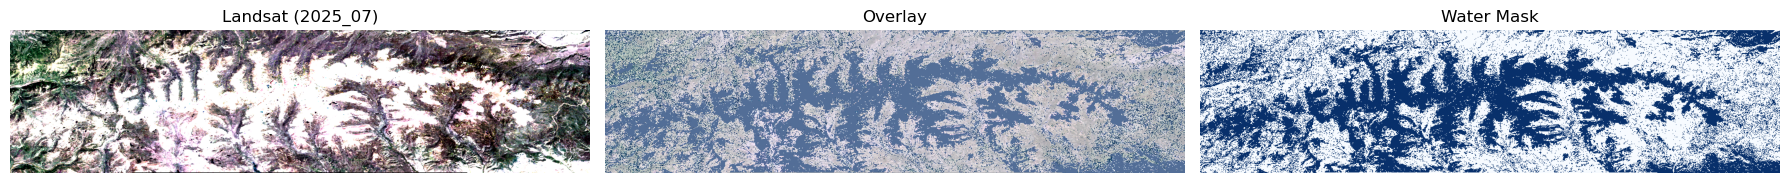

In [9]:
area = model_funcs.water_area_km2(mask, pixel_size_m=150)
print(f"Snow area: {area:.2f} km²")


plotting.plot_image_overlay_mask(input_filepath, mask, date=date)
